In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)

# Load dataset
df = pd.read_csv(r"./data/Heart Disease data set.csv")  # Make sure 'target' column exists


In [2]:
import pandas as pd

# Use double backslashes or raw string to fix file path issue
df = pd.read_csv(r"./data/Heart Disease data set.csv")  

# Checking if the dataset loads correctly
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
df.shape

(1025, 14)

In [8]:
for col in df:
    print(f"{col} has {df[col].unique()}  values. \n")

age has [52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]  values. 

sex has [1 0]  values. 

cp has [0 1 2 3]  values. 

trestbps has [125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]  values. 

chol has [212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 1

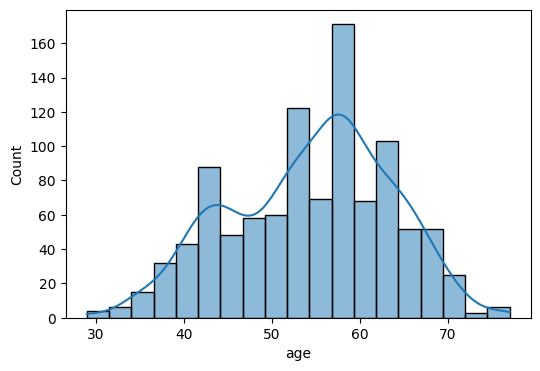

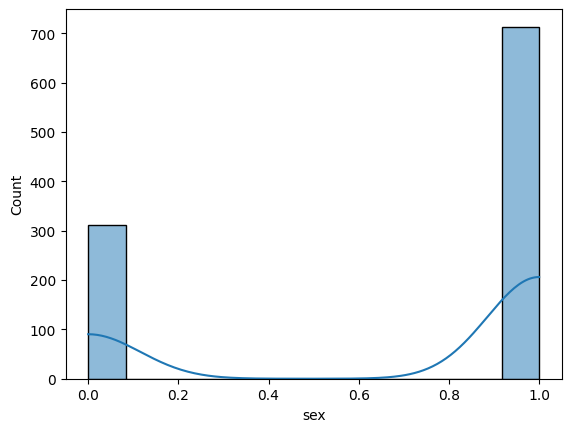

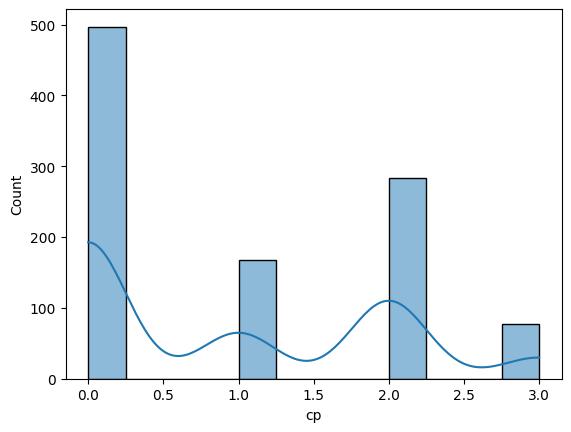

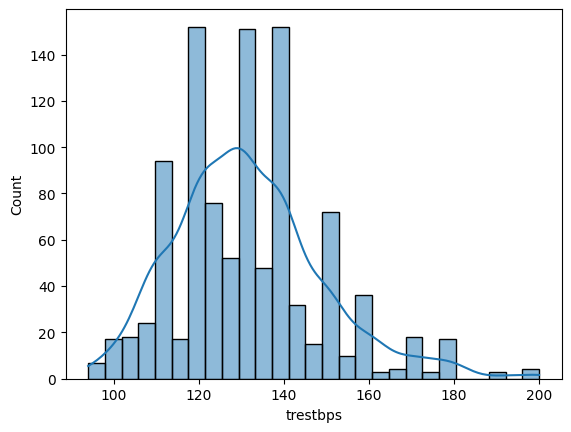

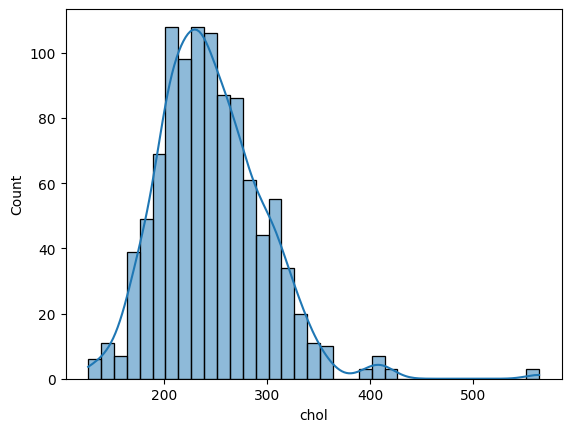

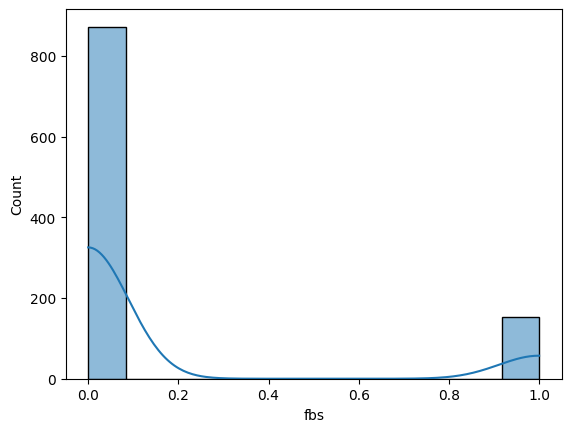

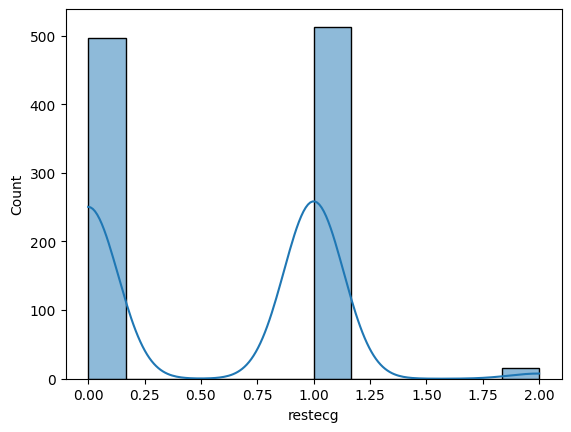

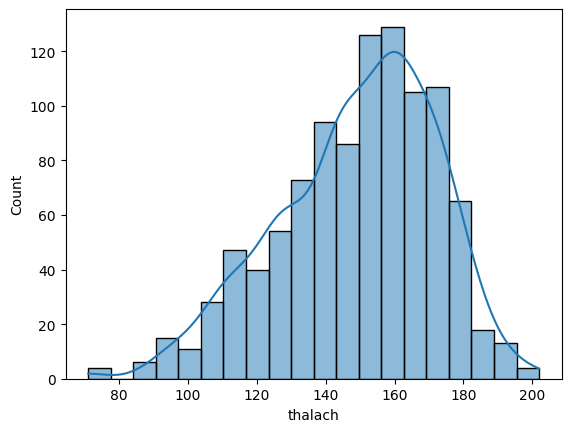

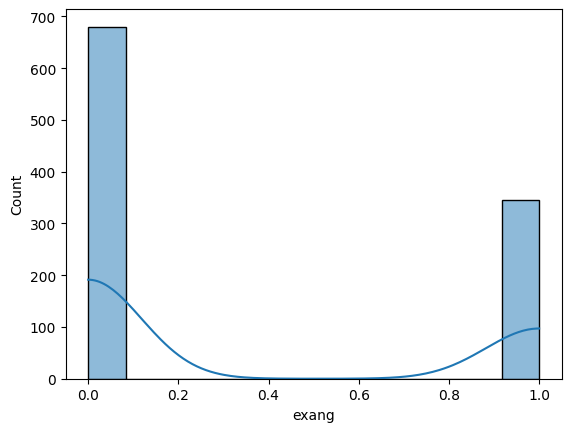

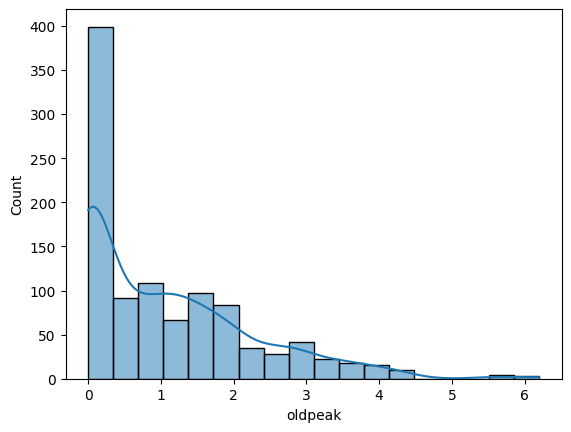

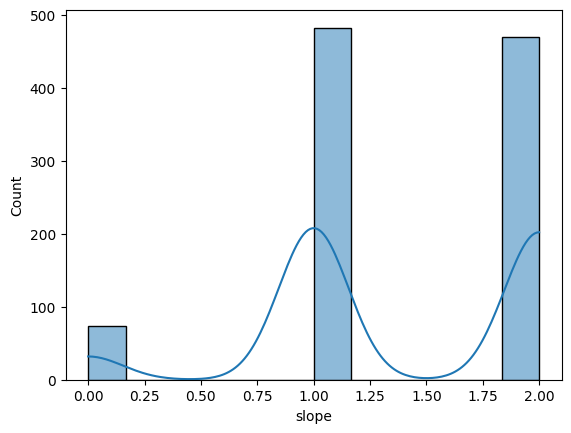

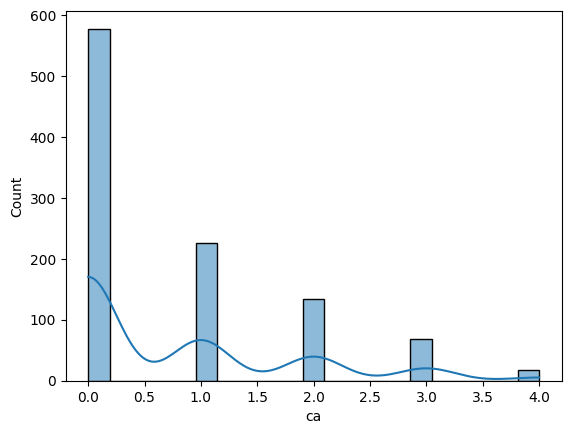

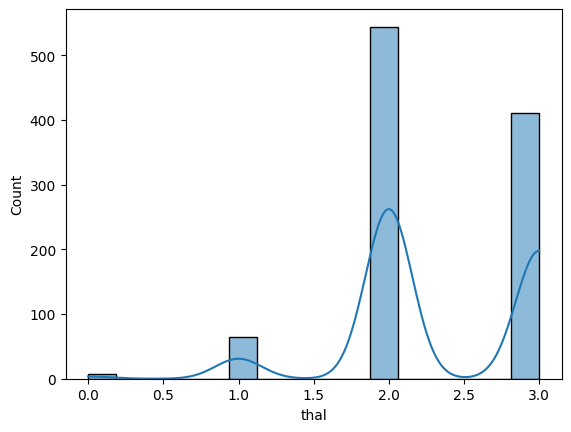

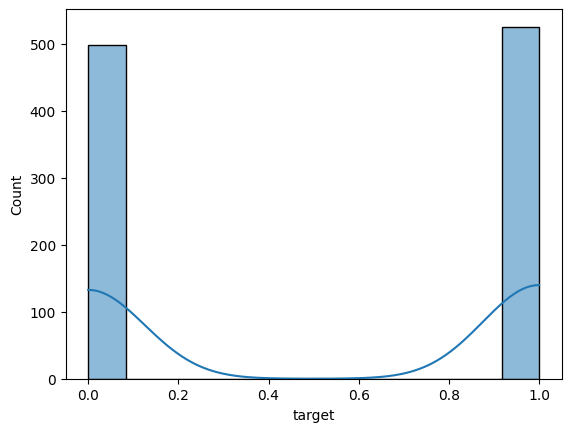

In [9]:
plt.figure(figsize=(6,4))

for col in df:
    sns.histplot(data=df,x=col,kde=True)
    print("\n")
    plt.show()

In [10]:
numerical_columns= df.columns[df.dtypes!="object"]

In [11]:
numerical_columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: >

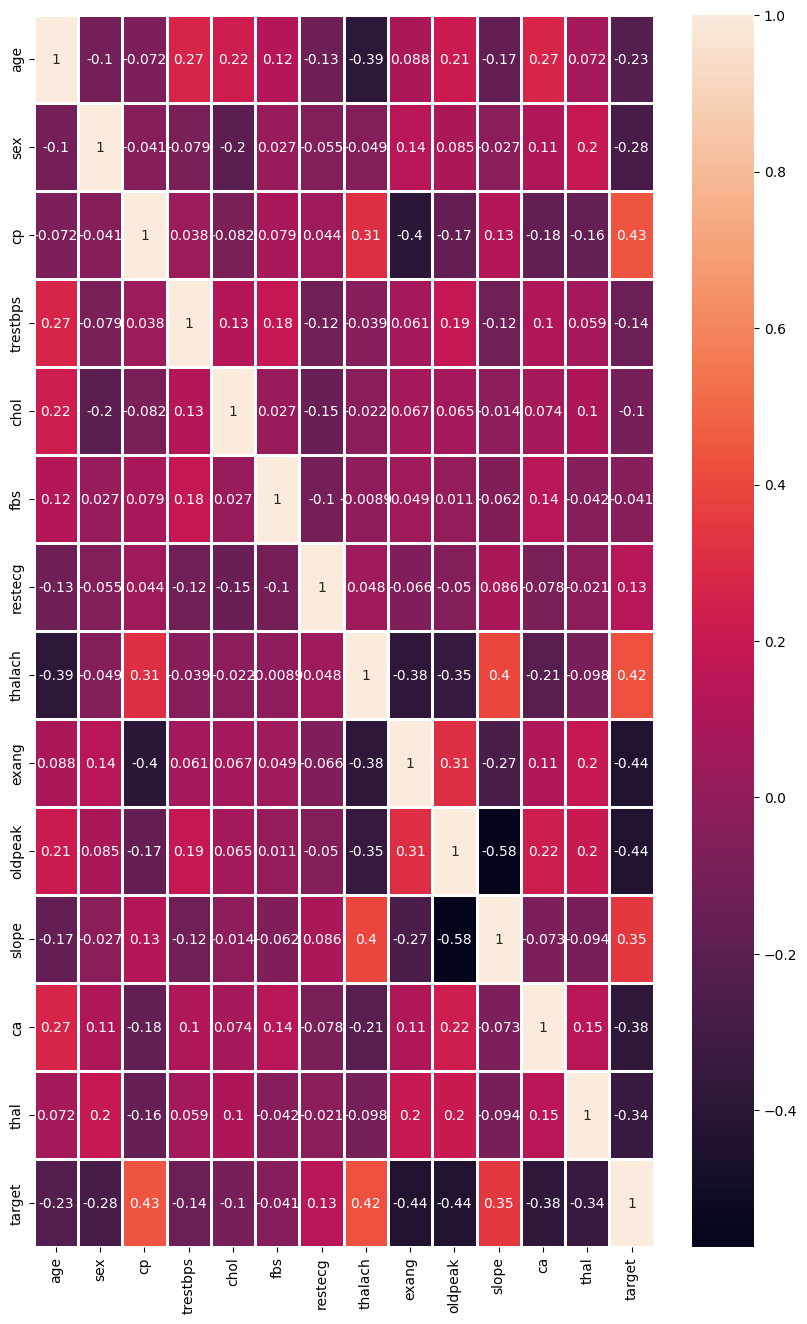

In [12]:
#COLUMNS WHICH ARE HIGHLY CORRELATED
plt.figure(figsize=(10, 16))
sns.heatmap(df[numerical_columns].corr(),annot=True,linewidths=1)

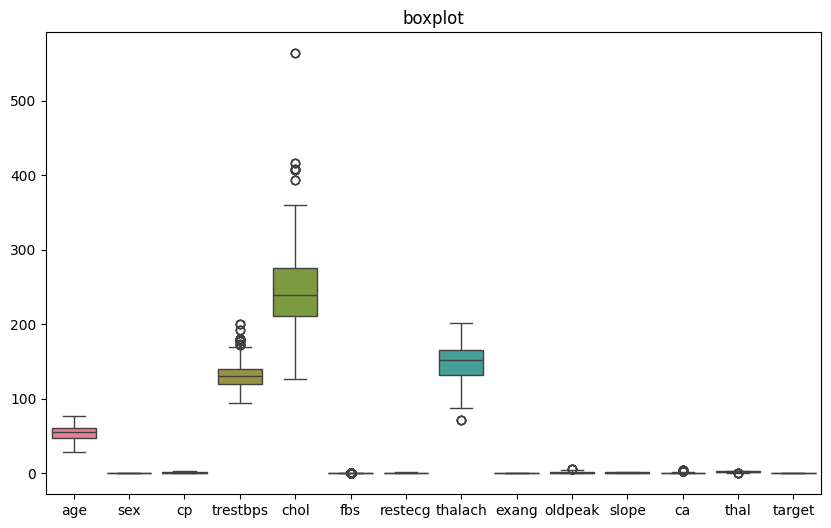

In [13]:
#DETERMINING THE OUTLIERS IN DATA
plt.figure(figsize=(22,6))
plt.subplot(1,2,2)
sns.boxplot(data = df)
plt.title("boxplot")

plt.show()

In [14]:
lower_cap = df["trestbps"].quantile(0.05)
upper_cap = df["trestbps"].quantile(0.95)

In [15]:
lower_cap

np.float64(108.0)

In [16]:
upper_cap

np.float64(163.19999999999982)

In [17]:
df['trestbps_capped'] = np.where(df['trestbps'] < lower_cap, lower_cap,
                              np.where(df['trestbps'] > upper_cap, upper_cap, df['trestbps']))

In [18]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,trestbps_capped
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,125.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,140.0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,145.0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,148.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1,140.0
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0,125.0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0,110.0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1,110.0


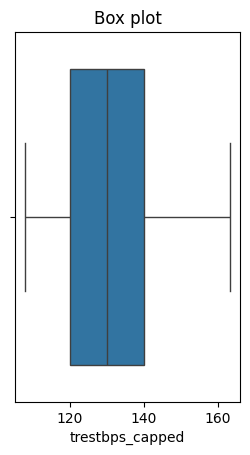

In [19]:
plt.subplot(1, 2, 2)
sns.boxplot(data = df, x  = 'trestbps_capped')
plt.title("Box plot")

plt.show()

In [20]:
lower_cap = df["chol"].quantile(0.05)
upper_cap = df["chol"].quantile(0.95)
df['chol_capped'] = np.where(df['chol'] < lower_cap, lower_cap,
                              np.where(df['chol'] > upper_cap, upper_cap, df['chol']))

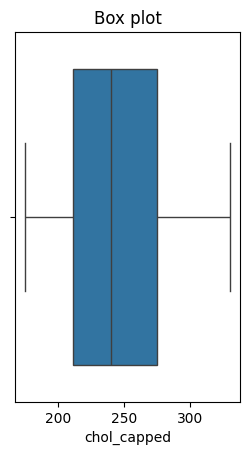

In [21]:
plt.subplot(1, 2, 2)
sns.boxplot(data = df, x  = 'chol_capped')
plt.title("Box plot")

plt.show()

In [22]:
lower_cap = df["thalach"].quantile(0.05)
upper_cap = df["thalach"].quantile(0.95)
df['thalach_capped'] = np.where(df['thalach'] < lower_cap, lower_cap,
                              np.where(df['thalach'] > upper_cap, upper_cap, df['thalach']))

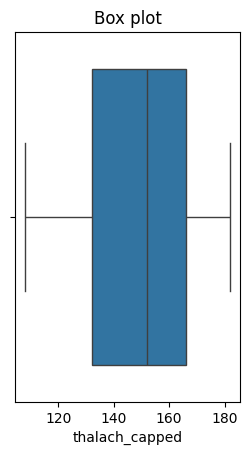

In [23]:
plt.subplot(1, 2, 2)
sns.boxplot(data = df, x  = 'thalach_capped')
plt.title("Box plot")

plt.show()

In [24]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,trestbps_capped,chol_capped,thalach_capped
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,125.0,212.0,168.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,140.0,203.0,155.0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,145.0,175.0,125.0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,148.0,203.0,161.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,138.0,294.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1,140.0,221.0,164.0
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0,125.0,258.0,141.0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0,110.0,275.0,118.0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1,110.0,254.0,159.0


In [25]:
X =df.drop("target",axis=1)
y= df["target"]

In [26]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,trestbps_capped,chol_capped,thalach_capped
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,125.0,212.0,168.0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,140.0,203.0,155.0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,145.0,175.0,125.0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,148.0,203.0,161.0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,138.0,294.0,108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,140.0,221.0,164.0
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,125.0,258.0,141.0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,110.0,275.0,118.0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,110.0,254.0,159.0


In [27]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [30]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,trestbps_capped,chol_capped,thalach_capped
788,62,0,0,138,294,1,1,106,0,1.9,1,3,2,138.0,294.0,108.0
679,68,1,2,180,274,1,0,150,1,1.6,1,0,3,163.2,274.0,150.0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,146.0,278.0,152.0
366,58,1,2,112,230,0,0,165,0,2.5,1,1,3,112.0,230.0,165.0
345,66,1,1,160,246,0,1,120,1,0.0,1,3,1,160.0,246.0,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,64,1,0,120,246,0,0,96,1,2.2,0,1,2,120.0,246.0,108.0
767,68,1,0,144,193,1,1,141,0,3.4,1,2,3,144.0,193.0,141.0
72,56,1,0,125,249,1,0,144,1,1.2,1,1,2,125.0,249.0,144.0
908,62,1,0,120,267,0,1,99,1,1.8,1,2,3,120.0,267.0,108.0


In [31]:
X_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,trestbps_capped,chol_capped,thalach_capped
49,60,1,0,117,230,1,1,160,1,1.4,2,2,3,117.0,230.0,160.0
525,51,0,2,130,256,0,0,149,0,0.5,2,0,2,130.0,256.0,149.0
119,42,1,1,120,295,0,1,162,0,0.0,2,0,2,120.0,295.0,162.0
629,65,1,3,138,282,1,0,174,0,1.4,1,1,2,138.0,282.0,174.0
186,40,1,0,110,167,0,0,114,1,2.0,1,0,3,110.0,175.0,114.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
663,58,0,0,100,248,0,0,122,0,1.0,1,0,2,108.0,248.0,122.0
185,57,1,0,165,289,1,0,124,0,1.0,1,3,3,163.2,289.0,124.0
286,64,0,2,140,313,0,1,133,0,0.2,2,0,3,140.0,313.0,133.0
1001,42,1,0,140,226,0,1,178,0,0.0,2,0,2,140.0,226.0,178.0


In [32]:
y_train

788    0
679    0
61     1
366    0
345    0
      ..
905    0
767    0
72     0
908    0
235    1
Name: target, Length: 717, dtype: int64

In [33]:
y_test

49      0
525     1
119     1
629     0
186     0
       ..
663     1
185     0
286     1
1001    1
808     1
Name: target, Length: 308, dtype: int64

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
classifier = DecisionTreeClassifier()

In [36]:
classifier

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
classifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
#postpruning
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy', max_depth = 2)

In [39]:
classifier

,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [40]:
classifier.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.8333333333333334, 'x[2] <= 0.5\nentropy = 0.998\nsamples = 717\nvalue = [338, 379]'),
 Text(0.25, 0.5, 'x[11] <= 0.5\nentropy = 0.836\nsamples = 346\nvalue = [254.0, 92.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'entropy = 1.0\nsamples = 160\nvalue = [82, 78]'),
 Text(0.375, 0.16666666666666666, 'entropy = 0.385\nsamples = 186\nvalue = [172, 14]'),
 Text(0.75, 0.5, 'x[9] <= 1.95\nentropy = 0.772\nsamples = 371\nvalue = [84, 287]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'entropy = 0.653\nsamples = 333\nvalue = [56.0, 277.0]'),
 Text(0.875, 0.16666666666666666, 'entropy = 0.831\nsamples = 38\nvalue = [28, 10]')]

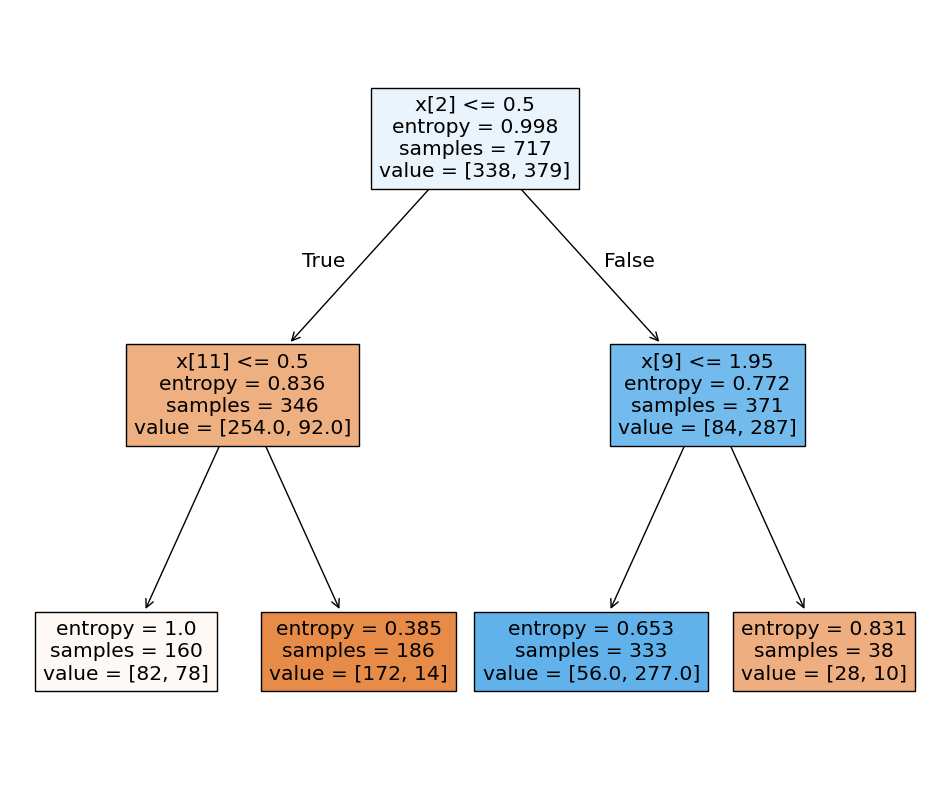

In [41]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(classifier,filled= True)

In [42]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,

In [43]:
#EVALUATION MATRIC
from sklearn.metrics import accuracy_score,classification_report

In [44]:
accuracy_score(y_test,y_pred)

0.7694805194805194

In [45]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78       161
           1       0.77      0.74      0.75       147

    accuracy                           0.77       308
   macro avg       0.77      0.77      0.77       308
weighted avg       0.77      0.77      0.77       308



In [47]:
# Load dataset
df =pd.read_csv("./data/Heart Disease data set.csv") # Replace with actual dataset
X = df.drop("target", axis=1)  # Features
y = df["target"]  # Target variable


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 820, Testing samples: 205


In [49]:
# Split features and target
X = df.drop('target', axis=1)
y = df['target']

In [50]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [52]:
#  Train the BaggingClassifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # Use 'estimator' instead of 'base_estimator'
    n_estimators=50,
    random_state=42
)

In [53]:
# Fit the model
bagging_model.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [54]:
#  Predictions and probabilities
y_pred = bagging_model.predict(X_test)
y_proba = bagging_model.predict_proba(X_test)[:, 1]

In [55]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

In [56]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

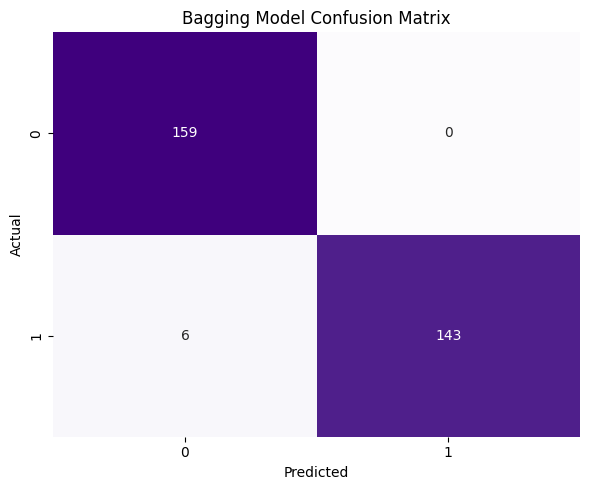

In [57]:
#  Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Bagging Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

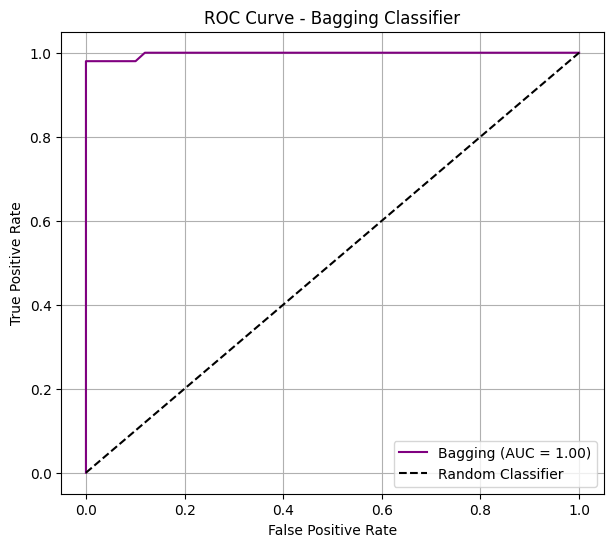

In [58]:
#  Plot ROC Curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Bagging (AUC = {roc_auc:.2f})", color='purple')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bagging Classifier")
plt.legend()
plt.grid()
plt.show()

In [59]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       159
           1       1.00      0.96      0.98       149

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308

